In [1]:
!pip install yfinance pandas numpy torch


In [1]:
!pip install yfinance pandas numpy matplotlib
import warnings

# Suppress only specific warnings (e.g., FutureWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
import yfinance as yf
import numpy as np

# Step 1: Download today's 1-minute data
ticker = "^NSEI"
data = yf.download(ticker, period="1d", interval="1m")

# Calculate returns
data['Return'] = data['Close'].pct_change()

# Calculate rolling volatility (using a 10-minute window if possible)
vol_window = 10 if len(data) >= 20 else 5
data['Volatility'] = data['Return'].rolling(window=vol_window).std()

# Use most recent volatility, fallback if needed
if data['Volatility'].dropna().empty:
    volatility = 0.02  # fallback if not enough data
    print("⚠️ Using fallback volatility value (0.02)")
else:
    volatility = float(data['Volatility'].dropna().iloc[-1])

# Get the latest closing price
last_price = data['Close'].iloc[-1]


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
# Simulation horizon (2 hours = 120 minutes)
n_steps = 120
dt = 1 / 390  # 1 minute as a fraction of a trading day
total_time = n_steps * dt

# Calculate today's price range
daily_range = data['High'].max() - data['Low'].min()
target_move = daily_range / 3

# Target bullish price = last price + 1/3 daily range
target_price_bull = last_price + target_move

# Required drift to reach that bullish target in expected value
required_bullish_drift = np.log(target_price_bull / last_price) / total_time

# Define scenario drifts
scenarios = {
    'bullish': required_bullish_drift,
    'bearish': -required_bullish_drift,
    'neutral': 0
}


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Sanity check and cast inputs as scalars
last_price = float(last_price)
volatility = float(volatility)
dt = float(dt)
n_simulations = 1000  # or whatever number of simulations you want
n_simulations = int(n_simulations)
n_steps = int(n_steps)

simulations = {}

# ✅ Run simulations
for name, scenario_drift in scenarios.items():
    scenario_drift = float(scenario_drift)  # Correctly extract the scalar value

    prices = np.zeros((n_simulations, n_steps))
    prices[:, 0] = last_price

    for step in range(1, n_steps):
        rand = np.random.standard_normal(n_simulations)
        drift_term = (scenario_drift - 0.5 * volatility**2) * dt
        diffusion_term = volatility * np.sqrt(dt) * rand
        prices[:, step] = prices[:, step - 1] * np.exp(drift_term + diffusion_term)

    simulations[name] = prices


In [4]:
def plot_scenario(name, prices, n_display=100):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.title(f"{name.capitalize()} Scenario - Monte Carlo Simulations", fontsize=16)
    plt.xlabel("Minutes into the Future")
    plt.ylabel("Price")

    # Plot sample paths
    for i in range(n_display):
        plt.plot(prices[i], color='blue', alpha=0.1)

    # Mean path
    mean_path = prices.mean(axis=0)
    plt.plot(mean_path, color='red', linewidth=2, label='Mean Path')

    # Current price reference
    plt.axhline(y=last_price, color='black', linestyle='--', label='Current Price')

    plt.legend()
    plt.grid(True)
    plt.show()

# 👉 Call this one at a time:
plot_scenario('bullish', simulations['bullish'])
# plot_scenario('neutral', simulations['neutral'])
# plot_scenario('bearish', simulations['bearish'])



NameError: name 'simulations' is not defined

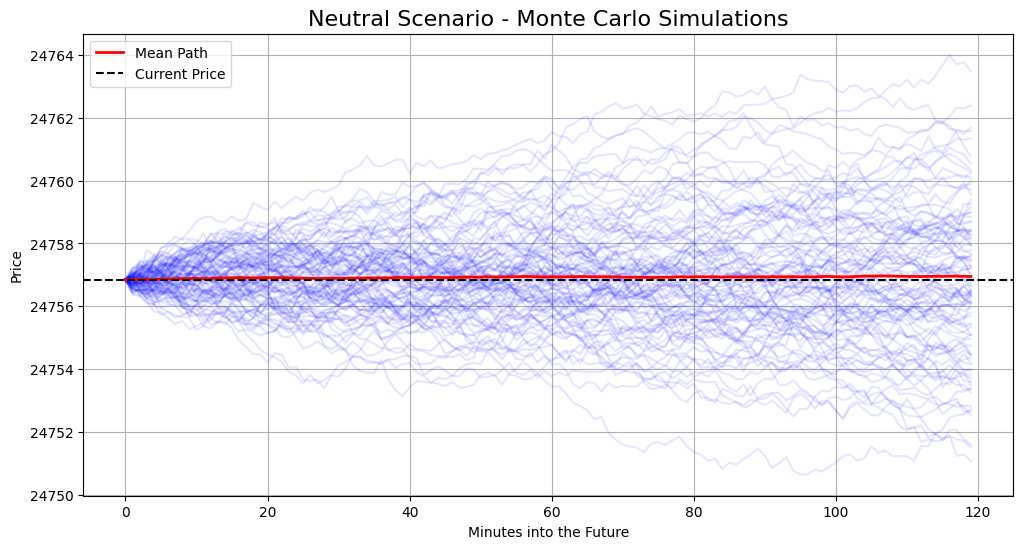

In [7]:
plot_scenario('neutral', simulations['neutral'])
# plot_scenario('bearish', simulations['bearish'])

In [5]:
# plot_scenario('neutral', simulations['neutral'])
plot_scenario('bearish', simulations['bearish'])

NameError: name 'simulations' is not defined

In [6]:
# Extract final expected prices
expected_bullish = simulations['bullish'].mean(axis=0)[-1]
expected_neutral = simulations['neutral'].mean(axis=0)[-1]
expected_bearish = simulations['bearish'].mean(axis=0)[-1]

# Sort levels for plotting
levels = sorted([
    ('Bullish', expected_bullish, 'green'),
    ('Neutral', expected_neutral, 'orange'),
    ('Bearish', expected_bearish, 'red')
], key=lambda x: x[1], reverse=True)

# Unpack sorted values
labels, prices, colors = zip(*levels)

# Plot
plt.figure(figsize=(8, 6))
plt.title("Expected Price Zones (Next 2 Hours)", fontsize=16)
plt.xlabel("Scenario")
plt.ylabel("Expected Price")

# Fill zones
for i in range(len(prices)-1):
    plt.axhspan(prices[i+1], prices[i], color=colors[i], alpha=0.2, label=f'{labels[i]} Zone')

# Price lines and labels
for label, price, color in levels:
    plt.hlines(price, xmin=0, xmax=1, colors=color, linestyles='--', linewidth=2)
    plt.text(1.02, price, f'{label}: {price:.2f}', va='center', color=color, fontsize=12)

# Plot current price
plt.axhline(last_price, color='blue', linestyle=':', linewidth=2, label=f'Current Price: {last_price:.2f}')

# No x-ticks, just vertical zones
plt.xticks([])
plt.grid(True, axis='y')
plt.legend(loc='best')
plt.tight_layout()
plt.show()



NameError: name 'simulations' is not defined

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import time
from datetime import datetime

# === LOCKED LEVELS ===
expected_bullish = 24826.36
expected_neutral = 24756.85
expected_bearish = 24687.85

buffer = (expected_bullish - expected_bearish) * 0.05  # 5% buffer

# === MAIN DASHBOARD LOOP ===
while True:
    # Step 1: Fetch latest intraday data (last 1 day, 5-minute intervals)
    df = yf.download("^NSEI", period="1d", interval="5m", progress=False)
    df.dropna(inplace=True)

    # Step 2: Get latest price
    last_price = float(df['Close'].iloc[-1])

    # Step 3: Ask trader's bias
    print(f"\n📊 [Intraday Price Zone Dashboard] - {datetime.now().strftime('%H:%M:%S')}")
    print("-" * 45)
    trader_bias = input("🧠 Your current bias based on price action? (buy/sell/neutral): ").strip().lower()

    # Step 4: Zone-based system logic
    system_bias = "neutral"
    zone_hint = "🔄 Moving sideways near neutral zone"

    if last_price > expected_neutral + buffer:
        system_bias = "buy"
        zone_hint = (
            "📈 Attempting to move toward bullish target"
            if last_price < expected_bullish - buffer
            else "✅ Near bullish expected price"
        )
    elif last_price < expected_neutral - buffer:
        system_bias = "sell"
        zone_hint = (
            "📉 Attempting to move toward bearish target"
            if last_price > expected_bearish + buffer
            else "✅ Near bearish expected price"
        )

    # Step 5: Sequence-based bias logic
    df['Change'] = df['Close'].diff()
    df['Direction'] = np.where(df['Change'] > 0, 'up', np.where(df['Change'] < 0, 'down', 'flat'))
    recent_directions = df['Direction'].dropna().iloc[-20:]
    up_count = (recent_directions == 'up').sum()
    down_count = (recent_directions == 'down').sum()
    sequence_bias = "neutral"
    if up_count / 20 > 0.6:
        sequence_bias = "buy"
    elif down_count / 20 > 0.6:
        sequence_bias = "sell"

    # Step 6: Final system bias combination
    if system_bias == sequence_bias and system_bias != "neutral":
        final_bias = system_bias
        match_note = f"✅ STRONG MATCH: Zone + Sequence agree ({final_bias.upper()})"
    elif system_bias != "neutral" and sequence_bias == "neutral":
        final_bias = system_bias
        match_note = f"ℹ️ Zone says {system_bias.upper()}, Sequence is indecisive"
    elif sequence_bias != "neutral" and system_bias == "neutral":
        final_bias = sequence_bias
        match_note = f"ℹ️ Sequence says {sequence_bias.upper()}, Zone is indecisive"
    else:
        final_bias = "neutral"
        match_note = "⚠️ Mixed signal. No strong bias."

    # Step 7: Display
    print(f"\n📍 Current Price: {last_price:.2f}")
    print(f"🔺 Bullish Target: {expected_bullish:.2f}")
    print(f"➖ Neutral Target: {expected_neutral:.2f}")
    print(f"🔻 Bearish Target: {expected_bearish:.2f}")
    print(f"📌 System Bias: {system_bias.upper()} - {zone_hint}")
    print(f"🧮 Sequence Bias: {sequence_bias.upper()}")
    print(f"🎯 Final Bias: {final_bias.upper()} - {match_note}")

    # Step 8: Trader confirmation logic
    if trader_bias == final_bias and final_bias != "neutral":
        print(f"\n✅ CONFIRMATION: Your bias ({trader_bias.upper()}) matches system.")
    elif trader_bias != final_bias and trader_bias in ["buy", "sell"]:
        print(f"\n⚠️ CAUTION: Your bias ({trader_bias.upper()}) ≠ system's bias ({final_bias.upper()})")
    else:
        print(f"\n⏸️ NO TRADE: Either neutral or mixed signals.")

    print("-" * 45)
    print("⏳ Waiting 30 seconds...\n")
    time.sleep(30)



📊 [Intraday Price Zone Dashboard] - 13:56:10
---------------------------------------------


🧠 Your current bias based on price action? (buy/sell/neutral):  sell



📍 Current Price: 24747.65
🔺 Bullish Target: 24826.36
➖ Neutral Target: 24756.85
🔻 Bearish Target: 24687.85
📌 System Bias: SELL - 📉 Attempting to move toward bearish target
🧮 Sequence Bias: NEUTRAL
🎯 Final Bias: SELL - ℹ️ Zone says SELL, Sequence is indecisive

✅ CONFIRMATION: Your bias (SELL) matches system.
---------------------------------------------
⏳ Waiting 30 seconds...


📊 [Intraday Price Zone Dashboard] - 13:56:55
---------------------------------------------


🧠 Your current bias based on price action? (buy/sell/neutral):  neutral



📍 Current Price: 24757.10
🔺 Bullish Target: 24826.36
➖ Neutral Target: 24756.85
🔻 Bearish Target: 24687.85
📌 System Bias: NEUTRAL - 🔄 Moving sideways near neutral zone
🧮 Sequence Bias: BUY
🎯 Final Bias: BUY - ℹ️ Sequence says BUY, Zone is indecisive

⏸️ NO TRADE: Either neutral or mixed signals.
---------------------------------------------
⏳ Waiting 30 seconds...


📊 [Intraday Price Zone Dashboard] - 13:59:37
---------------------------------------------


🧠 Your current bias based on price action? (buy/sell/neutral):  neutral



📍 Current Price: 24746.10
🔺 Bullish Target: 24826.36
➖ Neutral Target: 24756.85
🔻 Bearish Target: 24687.85
📌 System Bias: SELL - 📉 Attempting to move toward bearish target
🧮 Sequence Bias: NEUTRAL
🎯 Final Bias: SELL - ℹ️ Zone says SELL, Sequence is indecisive

⏸️ NO TRADE: Either neutral or mixed signals.
---------------------------------------------
⏳ Waiting 30 seconds...



**CRITICAL SL:-**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

# === Parameters ===
ticker = "^NSEI"
interval = "5m"
period = "1d"
confidence_level = 0.99  # 99% confidence

# === Step 1: Download intraday data
df = yf.download(ticker, interval=interval, period=period, progress=False)
df.dropna(inplace=True)

# === Step 2: Compute returns
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# === Step 3: Calculate VAR
var = np.percentile(df['Return'], (1 - confidence_level) * 100)

# === Step 4: Get latest price and SL
last_price = float(df['Close'].iloc[-1])
sl_value = abs(var * last_price)
stop_loss_price = last_price - sl_value

# === Step 5: Output
print(f"\n📊 VAR-Based Stop-Loss Calculator - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 50)
print(f"Ticker: {ticker}")
print(f"Latest Price: ${last_price:.2f}")
print(f"Confidence Level: {int(confidence_level * 100)}%")
print(f"Estimated VAR: {var:.4%}")
print(f"🔐 Stop-Loss Value: ${2*sl_value:.2f}")
print(f"📉 Suggested Stop-Loss Price: ${stop_loss_price:.2f}")
print("-" * 50)


YF.download() has changed argument auto_adjust default to True

📊 VAR-Based Stop-Loss Calculator - 2025-05-02 11:48:19
--------------------------------------------------
Ticker: ^NSEI
Latest Price: $24340.50
Confidence Level: 99%
Estimated VAR: -0.2526%
🔐 Stop-Loss Value: $122.96
📉 Suggested Stop-Loss Price: $24279.02
--------------------------------------------------


C:\Users\Shubham lodha\AppData\Local\Temp\ipykernel_1188\286209002.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(df['Close'].iloc[-1])
